In [1]:
!uv pip install quantities numpy matplotlib elephant scipy neo pyocclient tqdm

Using Python 3.12.13 environment at: /usr
Resolved 22 packages in 2.64s
Prepared 4 packages in 674ms
Installed 4 packages in 28ms
 + elephant==1.2.1
 + neo==0.14.4
 + pyocclient==0.6
 + quantities==0.16.4


<a target="_blank" href="https://colab.research.google.com/github/ANDA-NI-2026/ANDA-Day4-Cortical-Variability-Dynamics/blob/main/02_firing_irregularity_and_isi_stats/02_exercises.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This session analyses spike trains from primary motor cortex using three complementary tools: raster plots to visualise trial-by-trial spike timing, the coefficient of variation (CV) to quantify firing irregularity, and local measures (CV2 and Lv) that remain accurate when the firing rate changes within a trial. Comparisons with the Fano factor from the previous session connect interval variability to count variability.

The data were kindly provided by Alexa Riehle, Institut de Neurosciences de la Timone (INT), Centre National de la Recherche Scientifique (CNRS) - Aix-Marseille Universite (AMU), UMR7289, 13005 Marseille, France. Use of this data outside of this teaching course is strictly prohibited. Data published under https://doi.org/10.12751/g-node.rz77m8.

## Setup

### Import Libraries

In [2]:
import glob
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import elephant.statistics
import elephant.spike_train_generation
%matplotlib inline


### Utility Functions

Run the cell below to load the utility functions used in the exercises.

In [3]:
class utils:
    @staticmethod
    def load_neuron(mo_path, ts_path=None):
        mat = scipy.io.loadmat(mo_path)
        sf  = mat['SparseFormat'][0, 0]
        dt  = float(sf['TimeResolutionMS'][0, 0])
        def parse(sf_field):
            interval = sf_field['CutIntervalMS'][0]
            t_start  = float(interval[0])
            t_stop   = float(interval[1])
            result   = []
            for d in range(sf_field['Data'].shape[1]):
                matrix = sf_field['Data'][0, d].toarray()
                sts    = []
                for trial in range(matrix.shape[1]):
                    idx = np.where(matrix[:, trial])[0]
                    sts.append(t_start + idx * dt)   # numpy array of spike times in ms
                result.append(sts)
            return result, t_start, t_stop
        parsed, t_start, t_stop = parse(sf)
        out = {'mo': parsed, 't_start_ms': t_start, 't_stop_ms': t_stop}
        if ts_path is not None:
            mat2 = scipy.io.loadmat(ts_path)
            out['ts'] = parse(mat2['SparseFormat'][0, 0])[0]
        return out

    @staticmethod
    def pool_isis_in_window(sts, t0_ms, t1_ms):
        all_isi = []
        for st in sts:
            epoch = st[(st >= t0_ms) & (st < t1_ms)]
            if len(epoch) > 1:
                all_isi.extend(np.diff(epoch))
        return np.array(all_isi)

    @staticmethod
    def psth(sts, bin_ms=50, t_start=-1000, t_stop=1000):
        bins      = np.arange(t_start, t_stop + bin_ms, bin_ms)
        all_times = np.concatenate(sts)
        counts, _ = np.histogram(all_times, bins=bins)
        rate_hz   = counts / (len(sts) * bin_ms / 1000)
        centres   = (bins[:-1] + bins[1:]) / 2
        return centres, rate_hz

    @staticmethod
    def simulate_rate_step_trains(base_hz, step_hz, n_trains=200, t_half_ms=1000):
        """Poisson trains stepping from base_hz to step_hz at t_half_ms. Returns list of numpy arrays (ms)."""
        import quantities as pq
        import neo
        rate_arr = np.concatenate([np.full(t_half_ms, base_hz), np.full(t_half_ms, step_hz)])
        rate_sig = neo.AnalogSignal(rate_arr * pq.Hz, sampling_period=1 * pq.ms, t_start=0 * pq.ms)
        return [elephant.spike_train_generation.NonStationaryPoissonProcess(rate_sig)
                .generate_spiketrain().rescale(pq.ms).magnitude
                for _ in range(n_trains)]

    # --- plotting utilities ---------------------------------------------------

    @staticmethod
    def plot_raster(sts, ax=None, alignment_label='t = 0', title=None, ms=4, alignment_ms=0):
        """Plot a spike raster for a list of spike trains. Returns the axis."""
        if ax is None:
            _, ax = plt.subplots(figsize=(8, 4))
        for trial, st in enumerate(sts):
            ax.plot(st, np.full(len(st), trial), '|k', ms=ms)
        ax.axvline(alignment_ms, color='r', ls='--', label=alignment_label)
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Trial')
        if title:
            ax.set_title(title)
        ax.legend()
        return ax

    @staticmethod
    def plot_cv_hist(cvs, title=None):
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.hist(cvs, bins=10, color='steelblue', edgecolor='white')
        ax.axvline(1.0, color='r', ls='--', label='Poisson (CV = 1)')
        ax.set_xlabel('CV'); ax.set_ylabel('Count')
        if title: ax.set_title(title)
        ax.legend()

    @staticmethod
    def plot_cv_barchart(mean_cvs, xlabel='Direction'):
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.bar(range(len(mean_cvs)), mean_cvs, color='steelblue')
        ax.axhline(1.0, color='r', ls='--', label='Poisson (CV = 1)')
        ax.set_xlabel(xlabel); ax.set_ylabel('Mean CV')
        ax.set_xticks(range(len(mean_cvs))); ax.legend()

    @staticmethod
    def plot_isi_histograms(isis_list, labels, n_bins=40):
        n = len(isis_list)
        fig, axes = plt.subplots(1, n, figsize=(4 * n, 3), sharey=True)
        if n == 1: axes = [axes]
        for ax, isis, label in zip(axes, isis_list, labels):
            cv = isis.std() / isis.mean()
            ax.hist(isis, bins=n_bins, density=True, color='steelblue', edgecolor='white')
            ax.set_title(f'{label}\nCV = {cv:.3f}')
            ax.set_xlabel('ISI (ms)')
        axes[0].set_ylabel('Density')
        fig.tight_layout()

    @staticmethod
    def plot_psth(sts, bin_ms=50, t_start=-1000, t_stop=1000):
        centres, rate_hz = utils.psth(sts, bin_ms, t_start, t_stop)
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.bar(centres, rate_hz, width=bin_ms, color='steelblue', edgecolor='white')
        ax.axvline(0, color='r', ls='--', label='t = 0')
        ax.set_xlabel('Time (ms)'); ax.set_ylabel('Firing rate (Hz)')
        ax.legend()
        return centres, rate_hz

    @staticmethod
    def plot_measures_vs_rate(jump_rates, measures):
        _colors  = {'CV': 'steelblue', 'CV2': 'coral', 'Lv': 'seagreen'}
        _markers = {'CV': 'o', 'CV2': 's', 'Lv': '^'}
        fig, ax = plt.subplots(figsize=(6, 3))
        for label, values in measures.items():
            ax.plot(jump_rates, values,
                    _markers.get(label, 'o') + '-',
                    color=_colors.get(label, 'k'),
                    label=label)
        ax.axhline(1.0, color='k', ls='--', lw=0.8, label='Poisson expectation')
        ax.set_xlabel('Second-half rate (Hz)'); ax.set_ylabel('Mean value')
        ax.legend()

    @staticmethod
    def plot_cv_cv2_scatter(cv_all, cv2_all):
        lim = max(max(cv_all), max(cv2_all)) * 1.05
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(cv_all, cv2_all, s=15, alpha=0.5, color='steelblue')
        ax.plot([0, lim], [0, lim], 'k--', lw=1, label='CV = CV2')
        ax.axhline(1.0, color='r', ls=':', lw=1, label='Poisson (CV2 = 1)')
        ax.set_xlabel('CV'); ax.set_ylabel('CV2')
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.legend()


## Download Data

In [4]:
import os
import owncloud
from tqdm import tqdm

oc = owncloud.Client.from_public_link('https://uni-bonn.sciebo.de/s/m2pCDzgb2wq9d9a', folder_password='ibots')

os.makedirs('data', exist_ok=True)
for f in tqdm(oc.list('/'), desc='Downloading Files to data/'):
    if not os.path.exists(f'data{f.path}'):
        oc.get_file(f.path, f'data{f.path}')

/usr/local/lib/python3.12/dist-packages/owncloud/owncloud.py:602: SyntaxWarning: invalid escape sequence '\*'
  :param \*\*kwargs: optional arguments that ``put_file`` accepts
/usr/local/lib/python3.12/dist-packages/owncloud/owncloud.py:636: SyntaxWarning: invalid escape sequence '\*'
  :param \*\*kwargs: optional arguments that ``put_file`` accepts
/usr/local/lib/python3.12/dist-packages/owncloud/owncloud.py:1746: SyntaxWarning: invalid escape sequence '\*'
  :param \*\*kwargs: optional arguments that ``requests.Request.request`` accepts
/usr/local/lib/python3.12/dist-packages/owncloud/owncloud.py:1766: SyntaxWarning: invalid escape sequence '\*'
  :param \*\*kwargs: optional arguments that ``requests.Request.request`` accepts
/usr/local/lib/python3.12/dist-packages/owncloud/owncloud.py:1793: SyntaxWarning: invalid escape sequence '\*'
  :param \*\*kwargs: optional arguments that ``requests.Request.request`` accepts


### Load Recording Data

In [5]:
data = utils.load_neuron('data/joe096-5-C1-MO.mat', 'data/joe096-5-C1-TS.mat')

## Spike Train Rasters

In the present exercises, you will analyze single unit recordings from the primary motor
cortex (M1) of one monkey (monkey 1 in Rickert et al., 2009 and monkey M1 Rostami et al. 2024), which performed a delayed center-out task. The experiments were carried out in the lab of Alexa Riehle. The task and
the data are described in detail in Rickert et al., (2009). For an introduction to directional
tuning in the motor cortex an in-depth coverage is found in Riehle & Vaadia (2005).

Each trial of the experiment the monkey moved a cursor to one of 6 target directions. Spike trains are cut around two alignment events: movement onset (MO) and trial start (TS). The cell above loads the data of one neuron (neuron 5) of one recording session: `data['mo'][d]` is the list of spike trains of the individual trials of that neuron (numpy arrays of spike times in ms) for direction `d` (0-5) aligned to MO; `data['ts'][d]` provides the same trials aligned to TS.

### Code Reference

| Code                                                                                                      | Description |
|:----------------------------------------------------------------------------------------------------------| :-- |
| **`data['mo'][d]`**                                                                                       | Spike trains for direction d, aligned to movement onset |
| **`data['ts'][d]`**                                                                                       | Spike trains for direction d, aligned to trial start |
| **`utils.plot_raster(sts, ax=None, alignment_label='t = 0', title=None, alignment_ms=0)`**               | Plot a spike raster; mark `alignment_ms` with a red dashed line; returns the axis |

### Exercises

**Example**: Plot a spike raster for direction 0, aligned to MO.


<Axes: title={'center': 'Direction 0, MO-aligned'}, xlabel='Time (ms)', ylabel='Trial'>

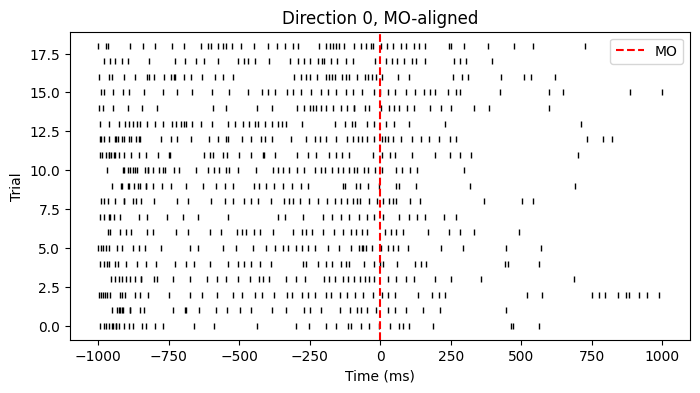

In [6]:
utils.plot_raster(data['mo'][0], alignment_label='MO', title='Direction 0, MO-aligned')


**Exercise**: Plot MO-aligned rasters for all 6 movement directions in a 2×3 grid with shared axes.

<Axes: title={'center': 'Direction 5, MO-aligned'}, xlabel='Time (ms)', ylabel='Trial'>

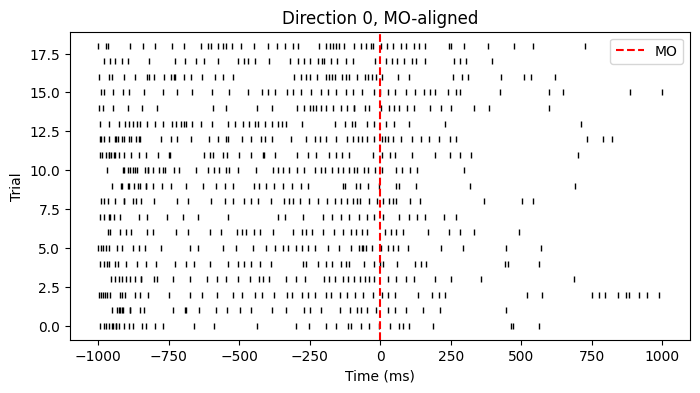

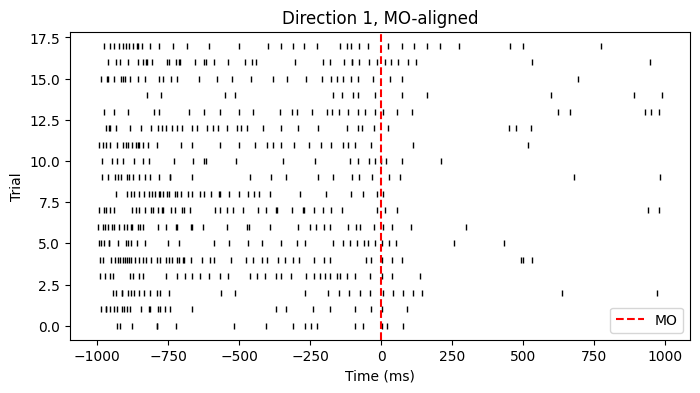

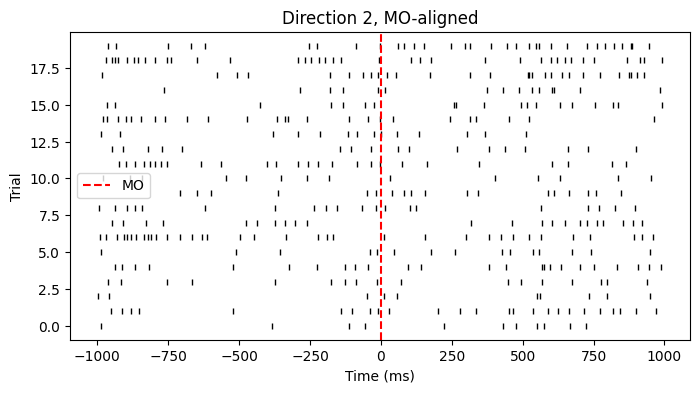

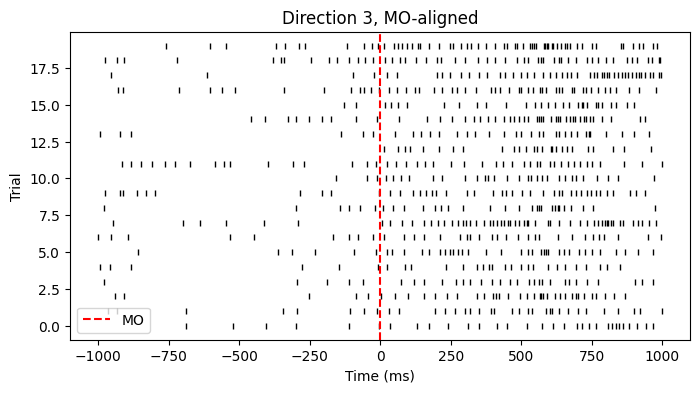

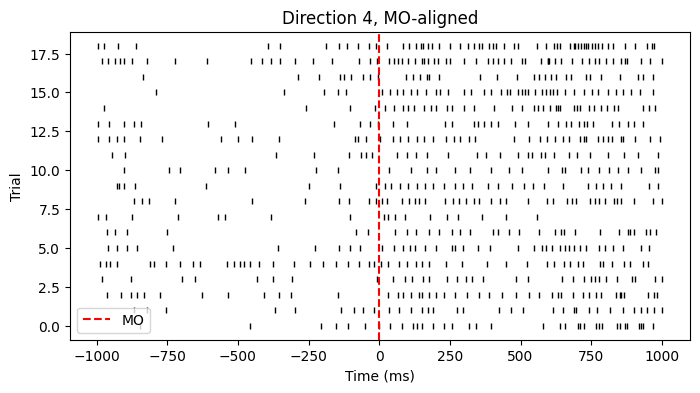

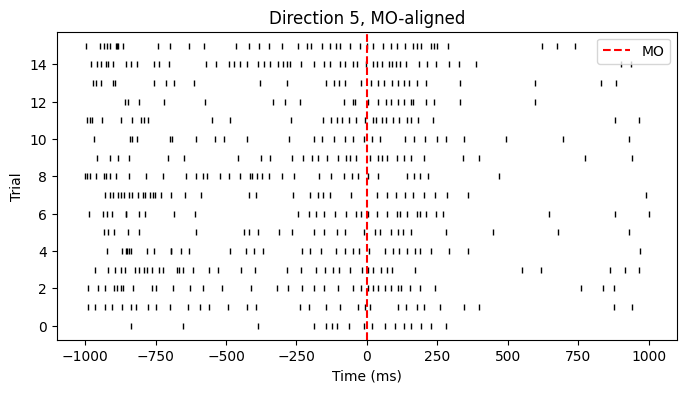

In [7]:
utils.plot_raster(data['mo'][0], alignment_label='MO', title='Direction 0, MO-aligned')
utils.plot_raster(data['mo'][1], alignment_label='MO', title='Direction 1, MO-aligned')
utils.plot_raster(data['mo'][2], alignment_label='MO', title='Direction 2, MO-aligned')
utils.plot_raster(data['mo'][3], alignment_label='MO', title='Direction 3, MO-aligned')
utils.plot_raster(data['mo'][4], alignment_label='MO', title='Direction 4, MO-aligned')
utils.plot_raster(data['mo'][5], alignment_label='MO', title='Direction 5, MO-aligned')

**Exercise**: Compare MO-aligned and TS-aligned rasters for direction 0 side by side using `utils.plot_raster`. How does the choice of alignment event affect the apparent structure of the spike trains across trials?


<Axes: title={'center': 'Direction 0, TS-aligned'}, xlabel='Time (ms)', ylabel='Trial'>

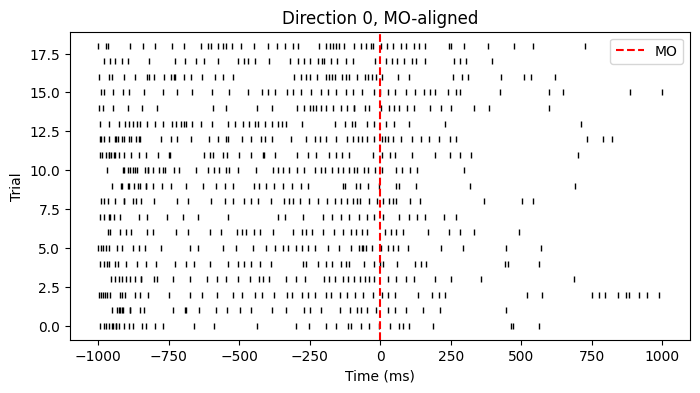

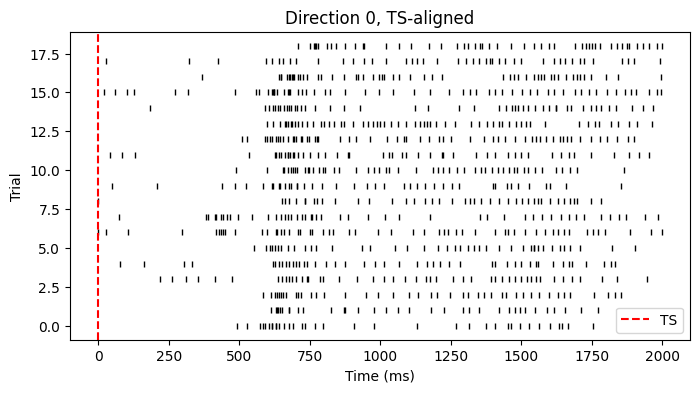

In [8]:
utils.plot_raster(data['mo'][0], alignment_label='MO', title='Direction 0, MO-aligned')
utils.plot_raster(data['ts'][0], alignment_label='TS', title='Direction 0, TS-aligned')

## Visualizing Rate Modulation

The rasters above already hint that firing rate is not constant within a trial: spike density visibly increases around movement onset. Before measuring irregularity, it is useful to see what a rate step looks like in a controlled, simulated setting (where the ground truth is known) and then to confirm the same structure in the real data.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`utils.simulate_rate_step_trains(base_hz, step_hz, n_trains=200, t_half_ms=1000)`** | Poisson trains stepping from base_hz to step_hz at t = t_half_ms ms |
| **`utils.plot_raster(sts, ax=None, alignment_label='t = 0', title=None, alignment_ms=0)`** | Plot a spike raster; mark `alignment_ms` with a red dashed line; returns the axis |

### Exercises

**Exercise**: Simulate 30 Poisson spike trains stepping from 20 Hz to 80 Hz at t = 1000 ms using `utils.simulate_rate_step_trains(20, 80, n_trains=30)`. Plot them as a raster with `utils.plot_raster`, placing the alignment marker at the rate step. What do you observe?


<Axes: xlabel='Time (ms)', ylabel='Trial'>

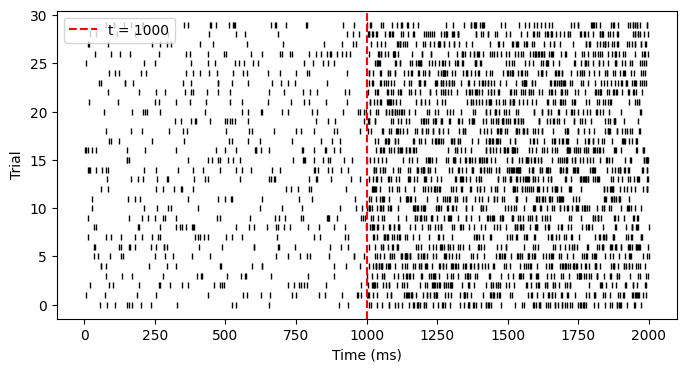

In [10]:
sts = utils.simulate_rate_step_trains(20, 80, n_trains=30)

utils.plot_raster(sts, alignment_label='t = 1000',alignment_ms=1000 )

**Exercise**: Compare rasters for three conditions side by side: 20→20 Hz (stationary control), 20→40 Hz, and 20→80 Hz, each with 30 trains. Which conditions show a visible rate change at t = 1000 ms?


<Axes: title={'center': '20->80'}, xlabel='Time (ms)', ylabel='Trial'>

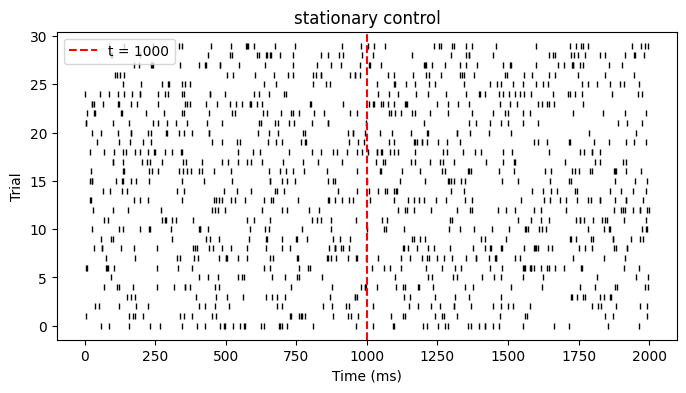

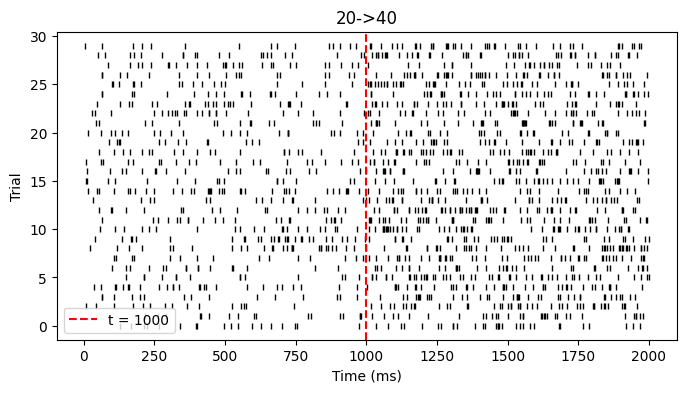

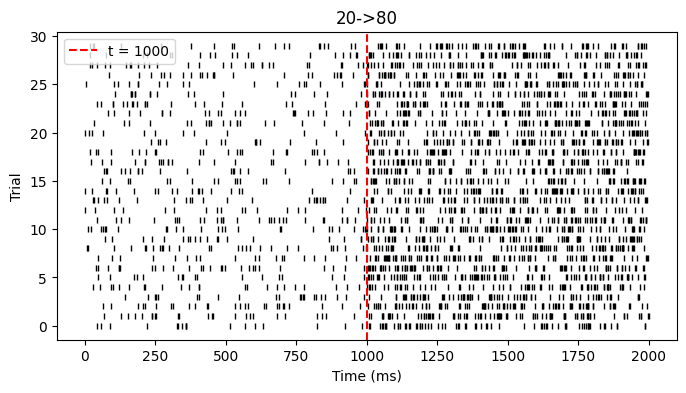

In [11]:
sts = utils.simulate_rate_step_trains(20, 20, n_trains=30)

utils.plot_raster(sts, alignment_label='t = 1000',alignment_ms=1000 ,title='stationary control')

sts = utils.simulate_rate_step_trains(20, 40, n_trains=30)

utils.plot_raster(sts, alignment_label='t = 1000',alignment_ms=1000 ,title='20->40')


sts = utils.simulate_rate_step_trains(20, 80, n_trains=30)

utils.plot_raster(sts, alignment_label='t = 1000',alignment_ms=1000 ,title='20->80')

## Firing Irregularity and the CV

The inter-spike interval (ISI) is the time between consecutive spikes. For a stationary spike train, the ISI distribution is interpretable in terms of point process theory, but this requires that the firing rate is constant within the analysis window. We begin with this assumption and will see shortly where it breaks down.

The coefficient of variation CV = σ_ISI / μ_ISI summarises the ISI distribution in a dimensionless number independent of the mean rate. For a homogeneous Poisson process (exponential ISIs), CV = 1. CV < 1 indicates more regular (sub-Poisson) firing; CV > 1 indicates bursty or clustered activity. Cortical neurons in the awake animal typically show CV ≈ 0.5-1.2 (Softky & Koch 1993; Shadlen & Newsome 1998).

For any stationary renewal process (each ISI drawn independently from the same distribution), the Fano factor and the squared CV are asymptotically linked (Cox & Lewis 1966; Nawrot 2010):

$$FF \approx CV^2$$

For a Gamma(κ) renewal process, CV = 1/√κ and FF ≈ 1/κ. The Poisson process is the special case κ = 1.

A fundamental limitation: ISI analysis is valid only when the firing rate is stationary within the observation window. In vivo, the rate often changes systematically within a trial (visible in the rasters: firing ramps up around movement onset). Pooling ISIs across such a window mixes intervals from different rate epochs and inflates CV beyond its intrinsic value. Two remedies are possible: (1) restrict analysis to a stationary sub-window identified from a PSTH, or (2) use local irregularity measures that compare only consecutive ISI pairs and are insensitive to slow rate drifts (next section).

You explored this rate-inflation effect in the homework. Here we quantify it directly by computing CV in short windows placed at and around the rate step, then confirm the pattern with a controlled rate-step simulation.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`elephant.statistics.isi(st)`** | ISIs for one spike train as a numpy array (ms) |
| **`elephant.statistics.cv(isi)`** | CV = std(ISI) / mean(ISI) |
| **`utils.pool_isis_in_window(sts, t0_ms, t1_ms)`** | Pool ISIs from spikes in [t0, t1] ms across all trials |
| **`utils.plot_cv_hist(cvs)`** | Histogram of per-trial CVs with Poisson reference |
| **`utils.plot_psth(sts, bin_ms=50)`** | Compute and plot a PSTH; returns `(centres, rate_hz)` |
| **`utils.plot_isi_histograms(isis_list, labels)`** | Multi-panel ISI histograms with CV in the title |
| **`utils.simulate_rate_step_trains(base_hz, step_hz, n_trains=200)`** | Poisson trains stepping from base_hz to step_hz at 1000 ms |
| **`utils.plot_measures_vs_rate(jump_rates, measures)`** | Line plot of one or more irregularity measures vs rate |

### Exercises

**Example**: Compute and print mean ISI and CV for trial 0, direction 0, MO-aligned, ignoring that the data is highly non-stationary and therefore will yield an inflated CV.


In [12]:
st  = data['mo'][0][0]
isi = elephant.statistics.isi(st)            # numpy array of ISIs in ms
print(f'Mean ISI: {isi.mean():.1f} ms')
print(f'CV:       {elephant.statistics.cv(isi):.3f}')


Mean ISI: 44.5 ms
CV:       1.215


**Exercise**: Compute the per-trial CV for direction 0 (skip trials with fewer than 3 spikes).
Store the values in `cvs_d0` and plot the CVs across trials with `utils.plot_cv_hist()`. Print the mean CV.

In [ ]:
st  = data['mo'][0][0]
isi = elephant.statistics.isi(st)            # numpy array of ISIs in ms
print(f'Mean ISI: {isi.mean():.1f} ms')
print(f'CV:       {elephant.statistics.cv(isi):.3f}')

**Exercise**: Let's explore the non-stationarity of the data in more detail. Build a PSTH for direction 0 (all MO-aligned trials pooled, bin size 50 ms) using `utils.plot_psth()`. When does the firing rate begin to rise? When does it peak, and when does it start to stabilise? Use this as a guide to understand which post-movement windows are most non-stationary.


(array([-975., -925., -875., -825., -775., -725., -675., -625., -575.,
        -525., -475., -425., -375., -325., -275., -225., -175., -125.,
         -75.,  -25.,   25.,   75.,  125.,  175.,  225.,  275.,  325.,
         375.,  425.,  475.,  525.,  575.,  625.,  675.,  725.,  775.,
         825.,  875.,  925.,  975.]),
 array([57.89473684, 53.68421053, 45.26315789, 31.57894737, 18.94736842,
        23.15789474, 24.21052632, 18.94736842, 24.21052632, 27.36842105,
        21.05263158, 26.31578947, 22.10526316, 25.26315789, 35.78947368,
        26.31578947, 37.89473684, 40.        , 40.        , 34.73684211,
        36.84210526, 30.52631579, 24.21052632, 15.78947368, 14.73684211,
        15.78947368,  6.31578947,  5.26315789,  5.26315789,  5.26315789,
         6.31578947,  6.31578947,  2.10526316,  2.10526316,  4.21052632,
         4.21052632,  2.10526316,  3.15789474,  2.10526316,  2.10526316]))

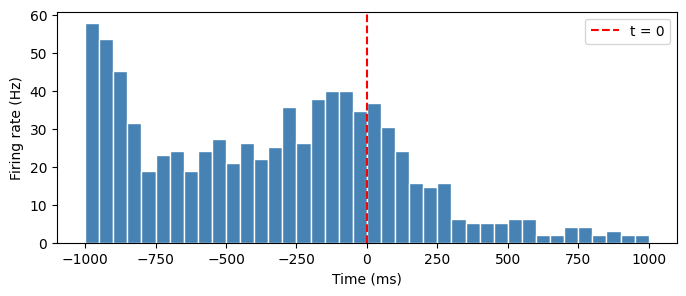

In [16]:
utils.plot_psth(data['mo'][0], bin_ms = 50)

**Exercise**: The PSTH above shows that firing rate shows both variable and stable periods. Let's see how the CV behaves in smaller windows, where activity is more stationary, thus likely to lead to less inflation. Pool ISIs from direction 0 (MO-aligned, all trials) in 400 ms windows that slide across the post-movement period.
Use `utils.pool_isis_in_window` and display the five ISI distributions side by side with `utils.plot_isi_histograms`. How does the ISI shape and CV change as you move away from the rate step? How does the CV differ from the one calculated across the whole data segment in the first exercises of this section?

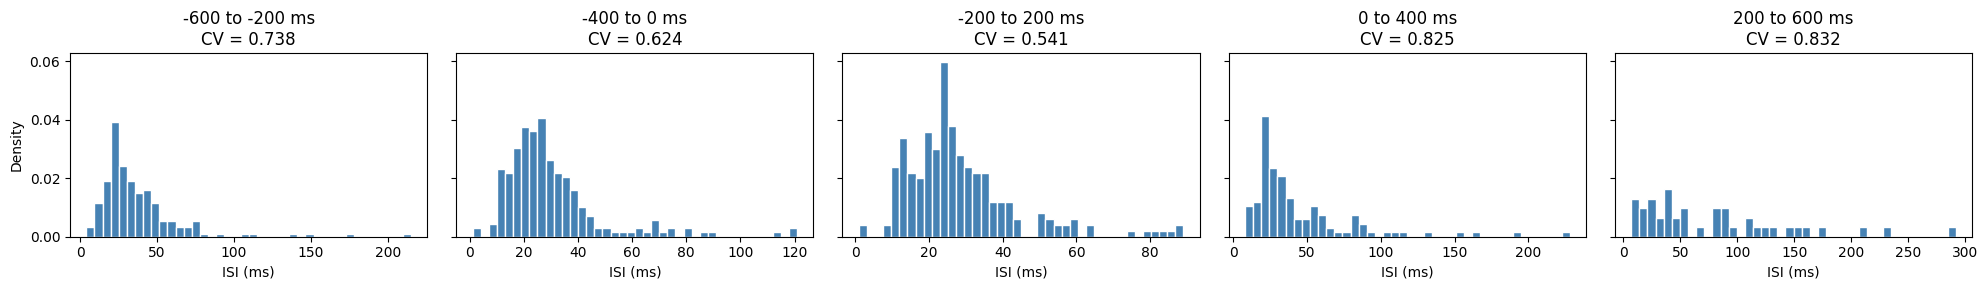

In [20]:
windows = [
    (-600, -200),  # Pre-movement stable
    (-400, 0),     # Around movement onset
    (-200, 200),   # Early post-movement
    (0, 400),      # Mid post-movement
    (200, 600)     # Late post-movement
]

isis_list = []
labels = []

for t_start, t_stop in windows:
    isis = utils.pool_isis_in_window(data['mo'][0], t_start, t_stop)
    isis_list.append(isis)
    labels.append(f'{t_start} to {t_stop} ms')

utils.plot_isi_histograms(isis_list, labels)

**Exercise**: Let's investigate in detail how a rate step can affect the CV measurement. For each step-to rate in `jump_rates = [20, 30, 40, 60, 80]` Hz,
simulate 200 Poisson trains with `utils.simulate_rate_step_trains(base_hz=20, step_hz=jump)`, similar to the rasters in the first section of this exercise.
Compute the mean CV per condition, store in `jump_cvs`, and plot with
`utils.plot_measures_vs_rate(jump_rates, {'CV': jump_cvs})`.


Mean CVs for different jump rates:
  20 Hz: 0.949
  30 Hz: 1.023
  40 Hz: 1.074
  60 Hz: 1.257
  80 Hz: 1.411


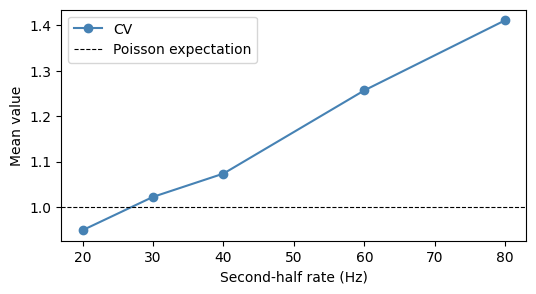

In [21]:
jump_rates = [20, 30, 40, 60, 80] # Hz
jump_cvs = []

# Store simulated spike trains for later use
sts_by_jump = []

for jump in jump_rates:
    # Simulate 200 Poisson trains
    sts = utils.simulate_rate_step_trains(base_hz=20, step_hz=jump, n_trains=200)
    sts_by_jump.append(sts)

    cvs_per_condition = []
    for st in sts:
        # Ensure there are enough spikes to calculate ISIs (at least 2 spikes)
        if len(st) >= 2:
            isi = elephant.statistics.isi(st)
            if len(isi) > 0:
                cv = elephant.statistics.cv(isi)
                cvs_per_condition.append(cv)

    # Calculate mean CV for the current condition
    if cvs_per_condition:
        jump_cvs.append(np.mean(cvs_per_condition))
    else:
        jump_cvs.append(np.nan) # Handle cases where no valid CVs could be computed

# Plot the results
utils.plot_measures_vs_rate(jump_rates, {'CV': jump_cvs})

print("Mean CVs for different jump rates:")
for rate, cv_val in zip(jump_rates, jump_cvs):
    print(f"  {rate} Hz: {cv_val:.3f}")

**Exercise**: Using `sts_by_jump`, pool ISIs across all 200 trains separately for three conditions:
20->20 Hz, 20->40 Hz, and 20->80 Hz. Pass them as `isis_list` to `utils.plot_isi_histograms()`.


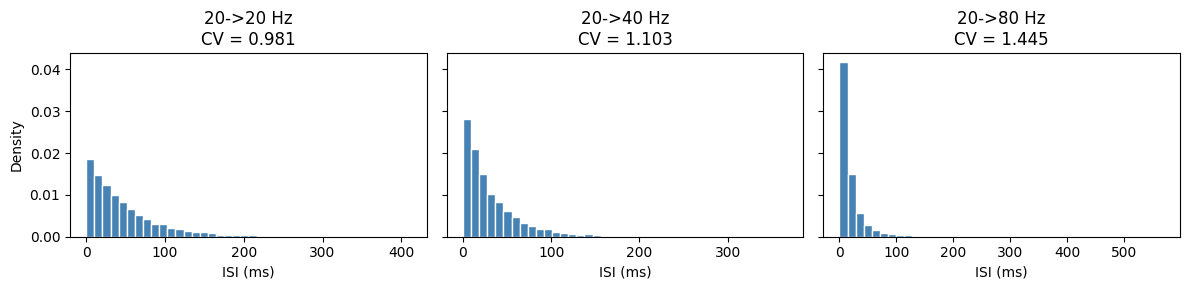

In [22]:
selected_jump_rates = [20, 40, 80]
pooling_isis_list = []
pooling_labels = []

# Assuming jump_rates and sts_by_jump are available from the previous cell
# jump_rates = [20, 30, 40, 60, 80]
# sts_by_jump is a list where sts_by_jump[i] corresponds to jump_rates[i]

for i, jump_rate in enumerate(jump_rates):
    if jump_rate in selected_jump_rates:
        all_isis_for_condition = []
        for st in sts_by_jump[i]:
            if len(st) >= 2:
                isi = elephant.statistics.isi(st)
                if len(isi) > 0:
                    all_isis_for_condition.extend(isi)

        if all_isis_for_condition:
            pool_isis = np.array(all_isis_for_condition)
            pooling_isis_list.append(pool_isis)
            pooling_labels.append(f'20->{jump_rate} Hz')

utils.plot_isi_histograms(pooling_isis_list, pooling_labels)


## Local Measures of Irregularity

When the firing rate changes within a trial, CV is inflated by rate modulation, as demonstrated in the previous section. Two closely related local measures address this by comparing only consecutive ISI pairs normalised by their local sum. This makes them insensitive to slow rate drifts: if the rate changes slowly, consecutive ISIs change together and their normalised difference remains close to its stationary value.

CV2 (Holt et al. 1996; Ponce-Alvarez et al. 2010):
$$CV_2 = \frac{2}{N}\sum_{i=1}^{N} \frac{|\tau_i - \tau_{i+1}|}{\tau_i + \tau_{i+1}}$$

Local Variation Lv (Shinomoto et al. 2003):
$$L_v = \frac{3}{N-1}\sum_{i=1}^{N-1} \frac{(\tau_i - \tau_{i+1})^2}{(\tau_i + \tau_{i+1})^2}$$

For a stationary Poisson process, CV2 = Lv = 1. For a stationary renewal process, CV2 ≈ Lv ≈ CV (all three converge). The key diagnostic: if CV >> CV2 (or Lv), the spike train is non-stationary within the observation window.

The two measures penalise ISI pair differences differently: CV2 uses the absolute difference (L1 penalty), so all deviations count equally regardless of size. Lv uses the squared difference (L2 penalty), giving disproportionately larger weight to pairs with very unequal consecutive ISIs. As a result, Lv is slightly more sensitive to extreme burstiness or pausing, while CV2 is more robust to individual outlier pairs. In practice, for typical cortical neurons both measures yield nearly identical results, and Lv = CV2 for a Poisson process (Ponce-Alvarez et al. 2010).

### Code Reference

| Code | Description |
| :-- | :-- |
| **`elephant.statistics.isi(st)`** | ISIs for one spike train as a numpy array (ms) |
| **`elephant.statistics.cv(isi)`** | CV = std(ISI) / mean(ISI) |
| **`elephant.statistics.cv2(isi)`** | CV2 for one spike train (Holt et al. 1996) |
| **`elephant.statistics.lv(isi)`** | Lv for one spike train (Shinomoto et al. 2003) |
| **`utils.plot_measures_vs_rate(jump_rates, measures)`** | Line plot of CV, CV2, Lv vs rate condition |
| **`utils.plot_cv_cv2_scatter(cv_all, cv2_all)`** | CV vs CV2 scatter with diagonal and Poisson reference |

### Exercises

**Example**: For direction 0, trial 0, MO-aligned, compute and compare CV, CV2, and Lv.

In [23]:
st  = data['mo'][0][0]
isi = elephant.statistics.isi(st)
print(f'CV  = {elephant.statistics.cv(isi):.3f}')
print(f'CV2 = {elephant.statistics.cv2(isi):.3f}')
print(f'Lv  = {elephant.statistics.lv(isi):.3f}')

CV  = 1.215
CV2 = 0.730
Lv  = 0.600


**Exercise**: Using `sts_by_jump` and `jump_cvs` from the previous section, compute mean CV2 and
mean Lv for each condition. Store in `jump_cv2s` and `jump_lvs`. Plot CV, CV2, and Lv together
with `utils.plot_measures_vs_rate(jump_rates, {'CV': jump_cvs, 'CV2': jump_cv2s, 'Lv': jump_lvs})`.

Restart point: re-run the simulation cell in the Firing Irregularity section to regenerate `sts_by_jump` and `jump_cvs`.


Mean CVs, CV2s, and Lvs for different jump rates:
  20 Hz: CV=0.949, CV2=0.993, Lv=0.983
  30 Hz: CV=1.023, CV2=0.999, Lv=1.001
  40 Hz: CV=1.074, CV2=1.002, Lv=1.004
  60 Hz: CV=1.257, CV2=1.017, Lv=1.027
  80 Hz: CV=1.411, CV2=0.999, Lv=1.000


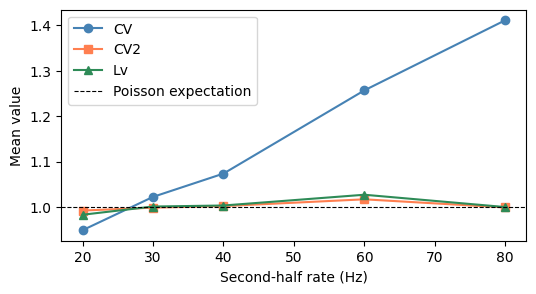

In [24]:
jump_cv2s = []
jump_lvs = []

for i, jump in enumerate(jump_rates):
    sts = sts_by_jump[i] # Get spike trains for the current jump rate

    cv2s_per_condition = []
    lvs_per_condition = []

    for st in sts:
        # CV2 and Lv require at least two ISIs, which means at least 3 spikes.
        # elephant.statistics.isi returns an empty array if less than 2 spikes.
        # elephant.statistics.cv2 and lv will raise an error if isi has < 2 elements.
        if len(st) >= 3: # Need at least 3 spikes for 2 ISIs to compute CV2/Lv
            isi = elephant.statistics.isi(st)
            if len(isi) >= 2: # Ensure there are at least two ISIs for CV2 and Lv
                cv2s_per_condition.append(elephant.statistics.cv2(isi))
                lvs_per_condition.append(elephant.statistics.lv(isi))

    # Calculate mean CV2 and Lv for the current condition
    if cv2s_per_condition:
        jump_cv2s.append(np.mean(cv2s_per_condition))
    else:
        jump_cv2s.append(np.nan) # Handle cases where no valid CV2s could be computed

    if lvs_per_condition:
        jump_lvs.append(np.mean(lvs_per_condition))
    else:
        jump_lvs.append(np.nan) # Handle cases where no valid Lvs could be computed

# Plot CV, CV2, and Lv together
utils.plot_measures_vs_rate(jump_rates, {'CV': jump_cvs, 'CV2': jump_cv2s, 'Lv': jump_lvs})

print("Mean CVs, CV2s, and Lvs for different jump rates:")
for rate, cv_val, cv2_val, lv_val in zip(jump_rates, jump_cvs, jump_cv2s, jump_lvs):
    print(f"  {rate} Hz: CV={cv_val:.3f}, CV2={cv2_val:.3f}, Lv={lv_val:.3f}")

**Exercise**: For each of the 6 directions, compute mean CV and mean CV2 per trial (MO-aligned, skip trials with fewer than 4 spikes). Print a summary table. Is CV consistently higher than CV2?

**Exercise**: Scatter CV vs. CV2 per trial for all 6 directions pooled (MO-aligned, ≥4 spikes). Add the diagonal CV = CV2 and a reference line at CV2 = 1. Most trials should fall above the diagonal, confirming that CV is inflated by within-trial rate modulation.

**Exercise**: Compare three estimates of firing irregularity pooled across all 6 directions:
(1) CV from the stable pre-movement epoch (-600 to -200 ms), (2) mean per-trial CV2,
and (3) mean per-trial Lv. Print a summary table. Do the three estimates agree?


## References

Avila-Akerberg O, Chacron MJ (2011) Nonrenewal spike train statistics: causes and functional consequences on neural coding. *Exp Brain Res* 210: 353-371.

Cox DR, Lewis PAW (1966) *The statistical analysis of series of events.* Chapman & Hall, London.

Farkhooi F, Strube-Bloss MF, Nawrot MP (2009) Serial correlation in neural spike trains. *Phys Rev E* 79: 021905.

Farkhooi F, Muller E, Nawrot MP (2011) Adaptation reduces variability of the neuronal population code. *Phys Rev E* 83: 050905.

Holt GR, Softky WR, Koch C, Douglas RJ (1996) Comparison of discharge variability in vitro and in vivo in cat visual cortex neurons. *J Neurophysiol* 75: 1806-1814.

Nawrot MP (2010) Analysis and interpretation of interval and count variability in neural spike trains. In: Grün S, Rotter S (eds) *Analysis of parallel spike trains.* Springer, New York, pp 34-58.

Ponce-Alvarez A, Kilavik BE, Riehle A (2010) Comparison of local measures of spike time irregularity and relating variability to firing rate in motor cortical neurons. *J Comput Neurosci* 29: 351-365.

Rickert J, Riehle A, Aertsen A, Rotter S, Nawrot MP (2009) Dynamic encoding of movement direction in motor cortical neurons. *J Neurosci* 29: 13870-13882.

Shadlen MN, Newsome WT (1998) The variable discharge of cortical neurons: implications for connectivity, computation, and information coding. *J Neurosci* 18: 3870-3896.

Softky WR, Koch C (1993) The highly irregular firing of cortical cells is inconsistent with temporal integration of random EPSPs. *J Neurosci* 13: 334-350.

Shinomoto S, Shima K, Tanji J (2003) Differences in spiking patterns among cortical neurons. *Neural Comput* 15: 2823-2842.

---

**Further Reading**

Nawrot MP et al. (2008) Measurements of variability dynamics in cortical spike trains. *J Neurosci Meth* 169: 374-390.

Riehle A, Vaadia E (eds, 2005) *Motor Cortex in Voluntary Movements.* CRC Press, Boca Raton.

Nawrot MP, Riehle A, Aertsen A, Rotter S (2003) Variability of motor cortical activity explained by network dynamics on multiple time scales. PhD thesis, Universität Freiburg.

Riehle A, Brochier T, Nawrot M, Grün S (2018) Behavioral context determines network state and variability dynamics in monkey motor cortex. *Front Neural Circuits* 12: 52.

Rostami V, Rost T, Schmitt FJ, van Albada SJ, Riehle A, Nawrot MP (2024) Spiking attractor model of motor cortex explains modulation of neural and behavioral variability by prior target information. *Nat Commun* 15: 6304.

Shadlen MN, Newsome WT (1998) The variable discharge of cortical neurons. *J Neurosci* 18: 3870-3896.